## Importación de Librerías y bd

In [2]:
import random
import time
import platform
import warnings

from tqdm.auto import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone

import pennylane as qml

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate
)

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.feature_selection import SequentialFeatureSelector

from funciones import graficar_box_hist_grid, graficar_metricas_forward, evaluar_forward


In [3]:
df = pd.read_csv('./data/raw/water_potability.csv',sep=",")

# Análisis de data

In [4]:
features = df.drop(columns=['Potability']).columns.tolist()
objetivo = 'Potability'

## Análisis de Variables

In [5]:
resumen_variables = (df[features].describe().T.drop(columns="count").rename(columns={    "mean": "promedio",    "std": "desviacion_estandar",    "min": "minimo",    "25%": "percentil_25",    "50%": "mediana",    "75%": "percentil_75",    "max": "maximo",})
)

resumen_variables.insert(0,"cantidad_vacios",df[features].isna().sum())

resumen_variables.insert(1,"porcentaje_vacios",df[features].isna().mean() * 100)

resumen_variables.style.format({"porcentaje_vacios": "{:.2f}%","promedio": "{:,.2f}","desviacion_estandar": "{:,.2f}","minimo": "{:,.2f}","percentil_25": "{:,.2f}","mediana": "{:,.2f}","percentil_75": "{:,.2f}","maximo": "{:,.2f}",
}).set_caption("Resumen descriptivo de las variables")

,cantidad_vacios,porcentaje_vacios,promedio,desviacion_estandar,minimo,percentil_25,mediana,percentil_75,maximo
ph,491,14.99%,7.08,1.59,0.00,6.09,7.04,8.06,14.00
Hardness,0,0.00%,196.37,32.88,47.43,176.85,196.97,216.67,323.12
Solids,0,0.00%,"22,014.09","8,768.57",320.94,"15,666.69","20,927.83","27,332.76","61,227.20"
Chloramines,0,0.00%,7.12,1.58,0.35,6.13,7.13,8.11,13.13
Sulfate,781,23.84%,333.78,41.42,129.00,307.70,333.07,359.95,481.03
Conductivity,0,0.00%,426.21,80.82,181.48,365.73,421.88,481.79,753.34
Organic_carbon,0,0.00%,14.28,3.31,2.20,12.07,14.22,16.56,28.30
Trihalomethanes,162,4.95%,66.40,16.18,0.74,55.84,66.62,77.34,124.00
Turbidity,0,0.00%,3.97,0.78,1.45,3.44,3.96,4.50,6.74


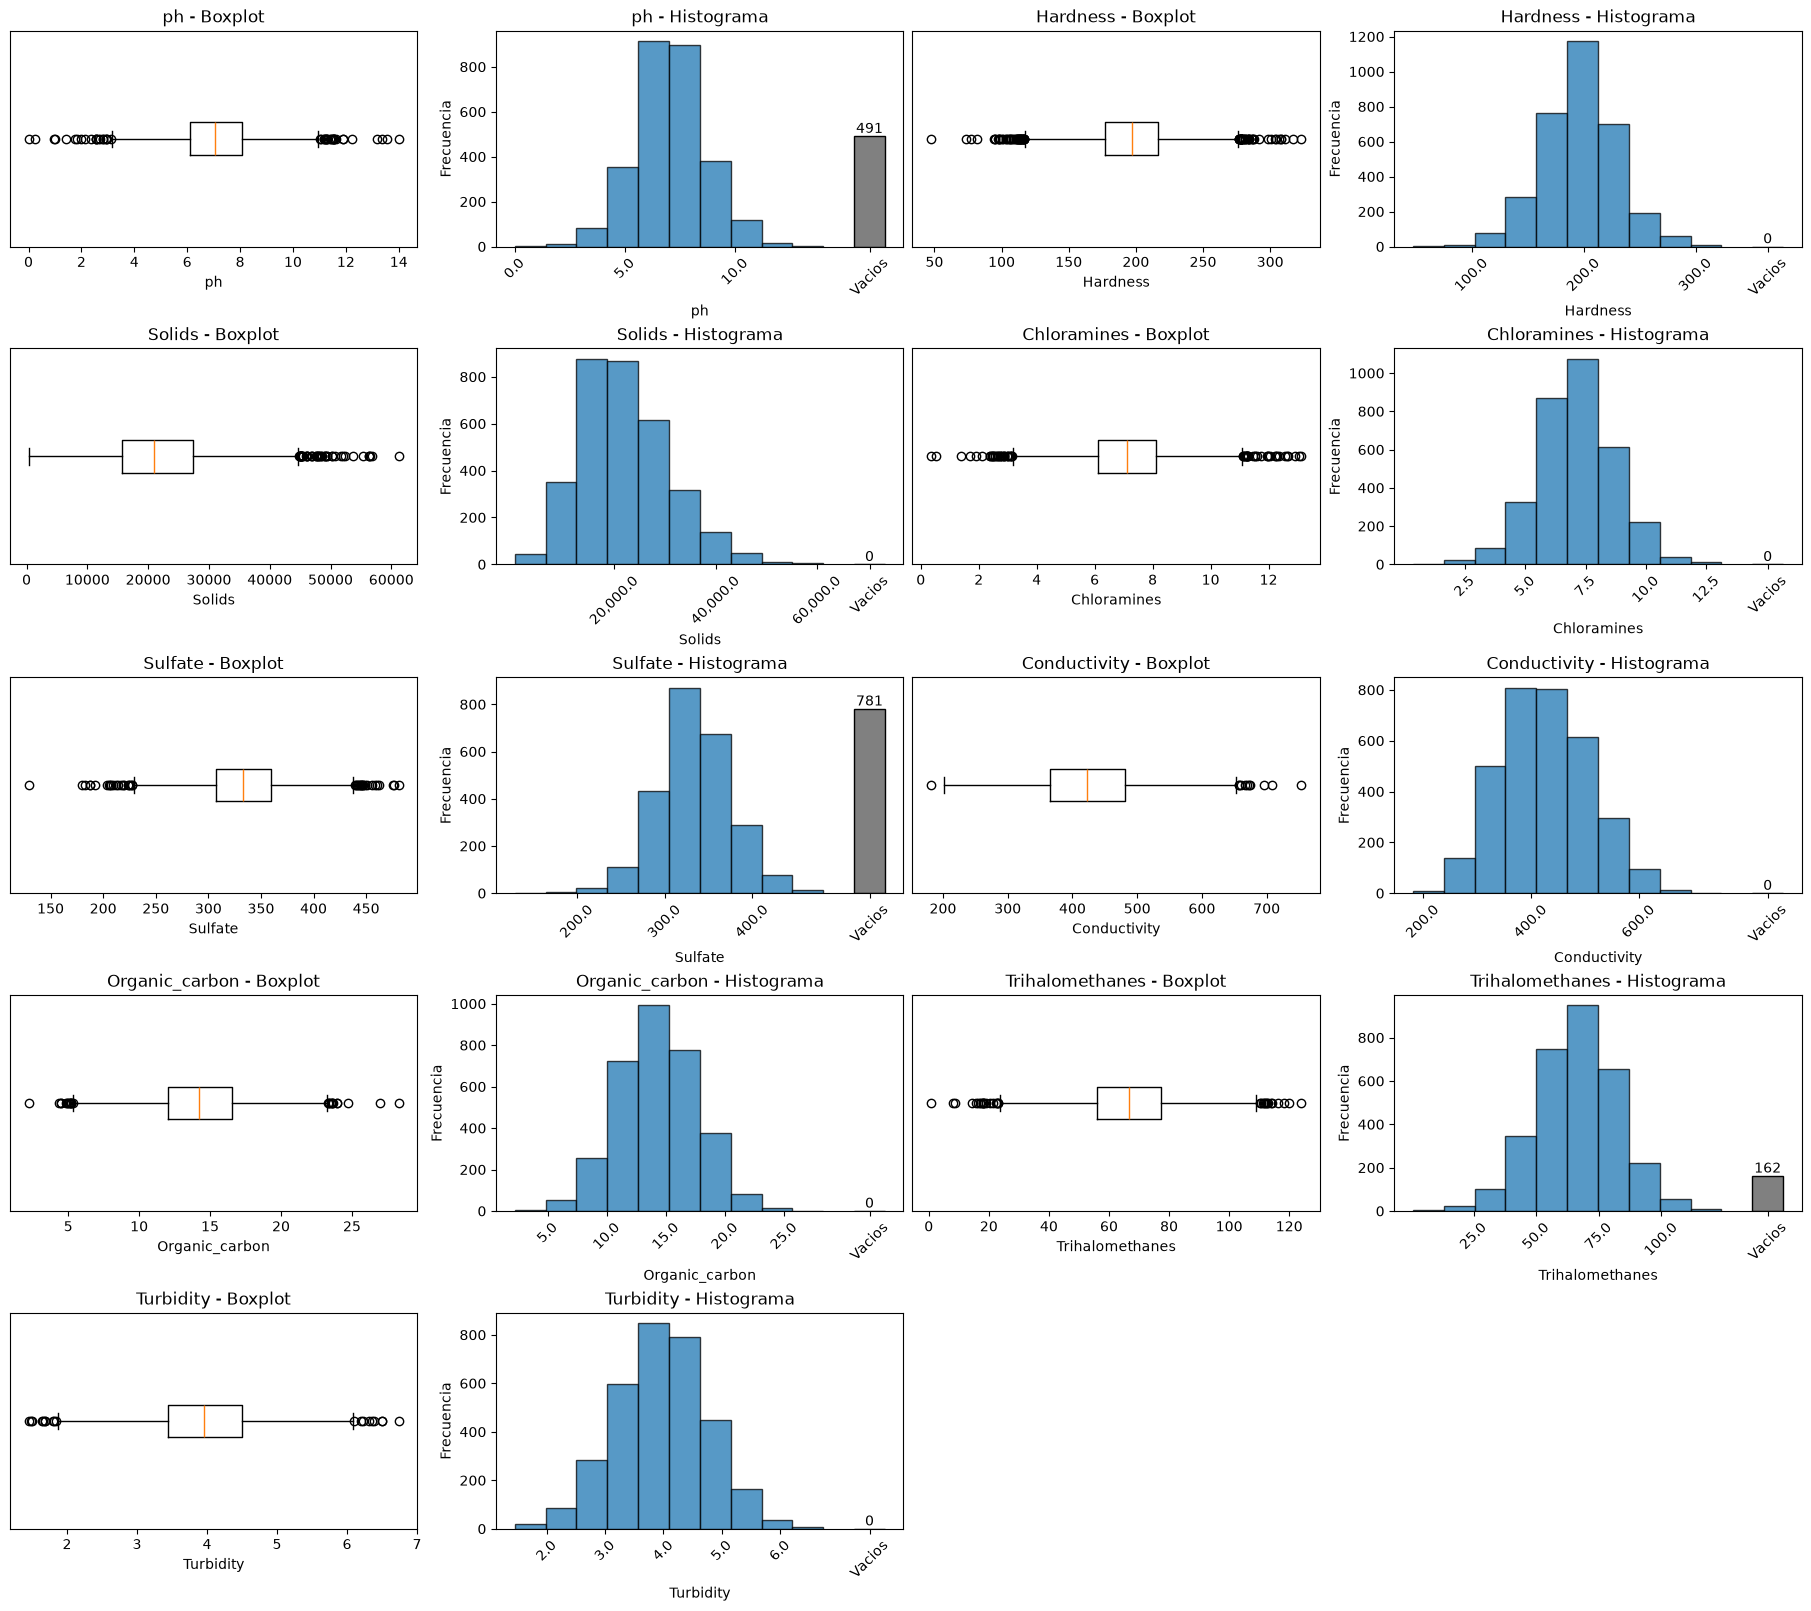

In [6]:
fig, axes = graficar_box_hist_grid(df, features, variables_por_fila=2, num_bins=10)
plt.show()

## Tratamiento de datos
Previo a realiar la imputación , escalado o balanceado de datos, es importante separar la data test, de lo contrario puede afectar en las decisiones del entrenamiento. Esto se decide por el posible data leakage

In [7]:
x = df.drop(columns=['Potability']).copy()
y = df['Potability'].copy()

División estratificada

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, f"{y_train.mean()*100:.2f}% (potability = 1)")
print("Test :", X_test.shape, f"{y_test.mean()*100:.2f}% (potability = 1)")

Train: (2620, 9) 39.01% (potability = 1)
Test : (656, 9) 39.02% (potability = 1)


### Imputación de datos y el no uso de Undersampling
Para esta seccion se procederá a realizar imputación de datos, ya que existen features con valores vacíos, estos no son trabajables para el kernel cuántico (ni clasico). Además, es necesario que esta imputación se realice luego de la separación train/test, ya que se deben usar las medianas de la PARTE TRAIN. 

Por el lado de Undersampling es innecesario su uso ya que la tasa del evento es 60/40, lo que no corresponde a tener data desbalanceada, caso que si puede ser al llegar a muestras 70/30 u 80/20.

In [9]:
#Imputación features con vacíos (ph,sulfato, trihalometanos)

medianas_train = X_train.median()

X_train = X_train.fillna(
    medianas_train
)

X_test = X_test.fillna(
    medianas_train
)


Estandarización a promedio 1 y var 0 

In [10]:
scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# Modelización clásica SVM

## Selección de variables por forward
A continuación se revisa el número de variables que deberían usarse , en donde el costo sea tan alto, donde no se note una mejora de f1 ni auc

### Hiperparámetros modelo

In [11]:
svm = SVC(kernel="rbf",
          gamma="auto",
          C=10,
          class_weight="balanced"
          )

#Validación Cruzada estratificada
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

### Selección de variables por fordward

In [12]:
resultados_forward = evaluar_forward(
    X=X_train,
    y=y_train,
    modelo=svm,
    cv=cv
)

resultados_forward

evaluar_forward: 100%|██████████| 9/9 [01:08<00:00,  7.60s/it]


,numero_variables,f1_cv,auc_cv,recall_cv,variables
0,1,0.514045,0.521545,0.710392,[ph]
1,2,0.536311,0.561519,0.718168,"[ph, Hardness]"
2,3,0.510280,0.573809,0.619235,"[ph, Hardness, Chloramines]"
3,4,0.543251,0.687922,0.525509,"[ph, Hardness, Chloramines, Sulfate]"
4,5,0.583949,0.720728,0.569436,"[ph, Hardness, Solids, Chloramines, Sulfate]"
5,6,0.574632,0.714710,0.574376,"[ph, Hardness, Solids, Chloramines, Sulfate, C..."
6,7,0.579468,0.709219,0.585093,"[ph, Hardness, Solids, Chloramines, Sulfate, C..."
7,8,0.568922,0.708680,0.573343,"[ph, Hardness, Solids, Chloramines, Sulfate, C..."
8,9,0.563011,0.694906,0.581162,"[ph, Hardness, Solids, Chloramines, Sulfate, C..."


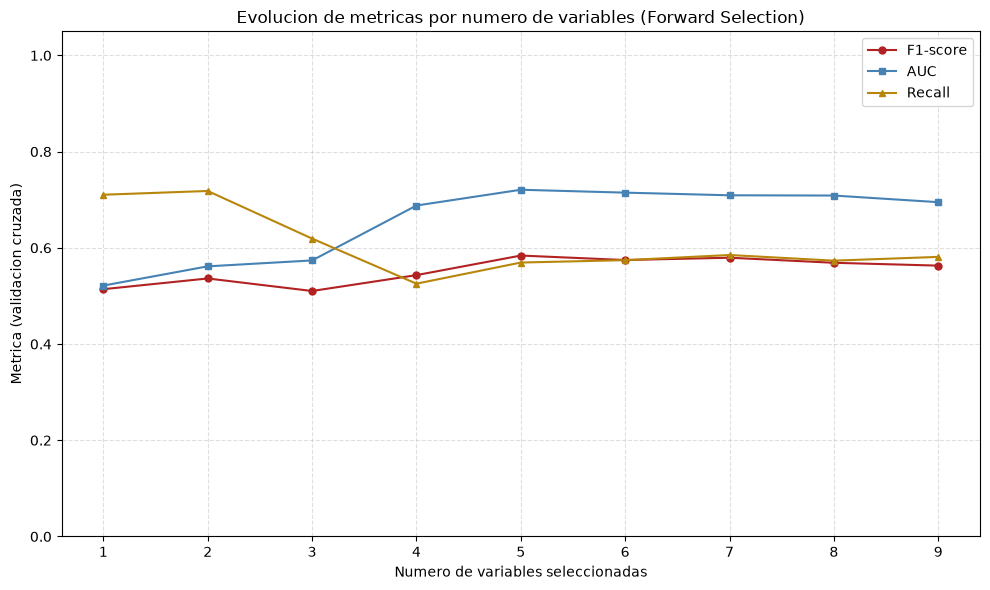

In [20]:
fig, ax = graficar_metricas_forward(resultados_forward)
plt.show()

### Modelo final con n_vars seleccionado

In [14]:
n_vars= 7

print("Variables seleccionadas:")
variables_finales = resultados_forward.iloc[n_vars-1]["variables"]
print(variables_finales)

#Se toman los dataset unicamente de las variables finales
X_train_selected = X_train[variables_finales].copy()
X_test_selected = X_test[variables_finales].copy()

Variables seleccionadas:
['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Trihalomethanes']


## Optimización de hiperparámetros de selección final

In [15]:
# Hiperparámetros que se van a probar
param_grid = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", "auto", 0.01],
}

#Búsqueda de los mejores parámetros
grid = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    scoring={
        "accuracy": "accuracy","precision": "precision","recall":"recall",
        "balanced_accuracy": "balanced_accuracy",
        "f1": "f1",
    },
    refit="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

## Se encuentran los hiperparámetros óptimos en donde no sufra un overfitting el modelo 
grid.fit(X_train_selected ,y_train)
cv_results = (
    pd.DataFrame(grid.cv_results_)[[
        "param_C",
        "param_gamma",
        "mean_test_accuracy",
        "mean_test_precision",
        "mean_test_recall",
        "mean_test_f1",
        "rank_test_f1",
    ]]
    .sort_values("rank_test_f1")
)

In [16]:
cv_results.head(1)

,param_C,param_gamma,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,rank_test_f1
7,10.0,auto,0.669466,0.574849,0.585093,0.579468,1


In [17]:
def classification_metrics(y_true, y_pred, scores=None):
    result = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    result["roc_auc"] = (
        roc_auc_score(y_true, scores) if scores is not None else np.nan
    )
    return result

## Modelización Final

In [18]:
classical_model = grid.best_estimator_

# Predicciones en train
y_pred_train = classical_model.predict(X_train_selected)
y_score_train = classical_model.decision_function(X_train_selected)

classical_metrics_train = classification_metrics(
    y_train,
    y_pred_train,
    y_score_train
)

# Predicciones en test
y_pred_test = classical_model.predict(X_test_selected)
y_score_test = classical_model.decision_function(X_test_selected)

classical_metrics_test = classification_metrics(
    y_test,
    y_pred_test,
    y_score_test
)

metrics_comparison = pd.DataFrame({
    "train": classical_metrics_train,
    "test": classical_metrics_test
})

# Diferencia absoluta
metrics_comparison["brecha_overfit"] = (
    metrics_comparison["train"]
    - metrics_comparison["test"]
)

# Diferencia relativa respecto a train
metrics_comparison["brecha_relativa_pct"] = np.where(
    metrics_comparison["train"] != 0,
    (
        metrics_comparison["brecha_overfit"]
        / metrics_comparison["train"]
    ) * 100,
    np.nan
)

metrics_comparison.index.name = "metrica"

display(
    metrics_comparison.style.format({
        "train": "{:.3f}",
        "test": "{:.3f}",
        "brecha_overfit": "{:.3f}",
        "brecha_relativa_pct": "{:.2f}%"
    })
)

,train,test,brecha_overfit,brecha_relativa_pct
metrica,,,,
accuracy,0.794,0.654,0.140,17.67%
precision,0.734,0.557,0.177,24.10%
recall,0.741,0.551,0.190,25.64%
f1,0.737,0.554,0.183,24.87%
roc_auc,0.868,0.668,0.200,23.04%


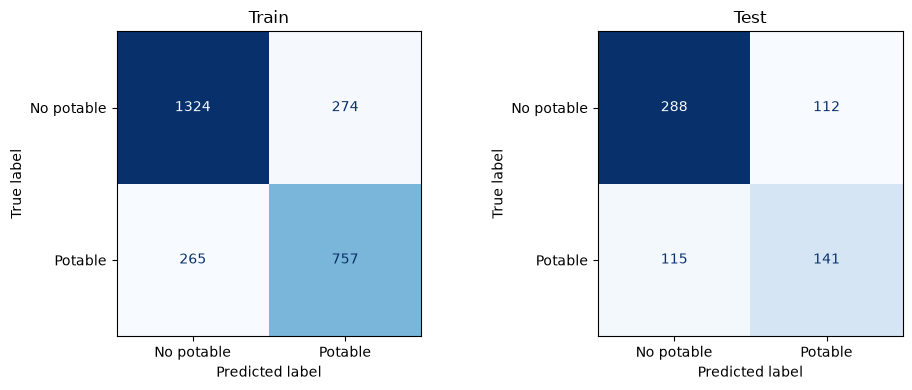

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Train
ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_pred_train,
    display_labels=["No potable", "Potable"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("Train")

# Test
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test,
    display_labels=["No potable", "Potable"],
    cmap="Blues",
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title("Test")

plt.tight_layout()
plt.show()